# Epsilon Fund — Strategy Testing
---

In [1]:
import pandas as pd
import numpy as np
import sys
import importlib
import matplotlib.pyplot as plt
import os


# ── Set your repo root path ────────────────────────────────────────────────────
ROOT = os.path.expanduser('~/Desktop/epsilon/github/Epsilon-Quant-Research')  # ← your Mac path
# ROOT = r'C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research'       # ← Dimitris Windows path (commented out)

# ──────────────────────────────────────────────────────────────────────────────


sys.path.append(os.path.join(ROOT, 'infrastructure', 'data'))
sys.path.append(os.path.join(ROOT, 'infrastructure', 'backtester'))
sys.path.append(os.path.join(ROOT, 'infrastructure', 'walkforward'))

# existing imports
from binance_client import get_binance_client
import engine
importlib.reload(engine)
from engine import backtest

# ✅ ADD THESE IMPORTS (adjust filename below)
from wf_engine import walk_forward, plateau_analysis, plateau_summary, perturbation_test, cost_stress_test

---
## Data

**Pairs** — any Binance pair in `BASEQUOTE` format (e.g. `BTCUSDT`, `ETHUSDT`, `SOLUSDT`, `BNBUSDT`).  
Verify availability at [binance.com/en/trade](https://www.binance.com/en/trade).

**Intervals** — `'1m'` `'5m'` `'15m'` `'1h'` `'4h'` `'1d'` `'1w'`

**Lookback** — days of history: `365` (1y) · `730` (2y) · `1825` (5y) · `2555` (7y, recommended minimum)

In [2]:
# =========================
# PAIR CONFIG
# =========================

Y = "TRXUSDT"
X = "LINKUSDT"

INTERVAL = "1d"
START = "2022-01-01"

lookback = 126
z_lookback = 60
entry = 1.8
exit = 0.5
pair_cost = 0.001

client = get_binance_client()

def load_symbol_close(symbol, interval="1d", start="2022-01-01"):
    raw = client.get_historical_klines(symbol, interval, start)

    df = pd.DataFrame(
        raw,
        columns=[
            "Time", "Open", "High", "Low", "Close", "Volume",
            "Close_time", "Quote_volume", "Trades",
            "Taker_base", "Taker_quote", "Ignore"
        ]
    )

    df = df[["Time", "Open", "High", "Low", "Close", "Volume"]].copy()
    df["Time"] = pd.to_datetime(df["Time"], unit="ms")
    df["Open"] = df["Open"].astype(float)
    df["High"] = df["High"].astype(float)
    df["Low"] = df["Low"].astype(float)
    df["Close"] = df["Close"].astype(float)
    df["Volume"] = df["Volume"].astype(float)
    df = df.set_index("Time").sort_index()

    return df

df_y = load_symbol_close(Y, INTERVAL, START)
df_x = load_symbol_close(X, INTERVAL, START)

pair_prices = pd.concat(
    [
        df_y["Close"].rename(Y),
        df_x["Close"].rename(X),
    ],
    axis=1
).dropna().sort_index()

print(pair_prices.head())
print(pair_prices.tail())
print(f"Rows: {len(pair_prices)}")

            TRXUSDT  LINKUSDT
Time                         
2022-01-01  0.07660     20.76
2022-01-02  0.07762     21.87
2022-01-03  0.07705     23.72
2022-01-04  0.07592     23.42
2022-01-05  0.07112     25.24
            TRXUSDT  LINKUSDT
Time                         
2026-04-03   0.3151      8.65
2026-04-04   0.3176      8.69
2026-04-05   0.3189      8.82
2026-04-06   0.3165      8.81
2026-04-07   0.3143      8.66
Rows: 1558


---
## Strategy

**Available columns:** `Open` `High` `Low` `Close` `Volume`

**Required output:** a `position` column — `1` long · `0` flat · `-1` short  
**Optional:** `position_size` column (0–1) to use fractional capital

> Signals are shifted 1 bar by the engine — no need to shift manually.

,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2022-07-04,0.776018,0.0,-0.065191,-0.500145,-0.118245,-2.418580,1.0
2022-07-05,0.783651,0.0,-0.054050,-0.394557,-0.115197,-2.424807,1.0
2022-07-06,0.777281,0.0,-0.060726,-0.416763,-0.112551,-2.431999,1.0
2022-07-07,0.793599,0.0,-0.039085,-0.216122,-0.109462,-2.438509,1.0
2022-07-08,0.794571,0.0,-0.037050,-0.177909,-0.106479,-2.445477,1.0


,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2026-04-03,4.020065,-1.0,0.077007,1.255237,-0.009633,-1.206348,1.0
2026-04-04,4.052181,0.0,0.083536,1.439931,-0.011830,-1.199798,1.0
2026-04-05,4.069626,0.0,0.086462,1.490159,-0.014199,-1.193576,1.0
2026-04-06,4.038923,0.0,0.077529,1.163323,-0.016428,-1.188287,1.0
2026-04-07,4.009593,0.0,0.069155,0.867176,-0.018234,-1.184418,1.0


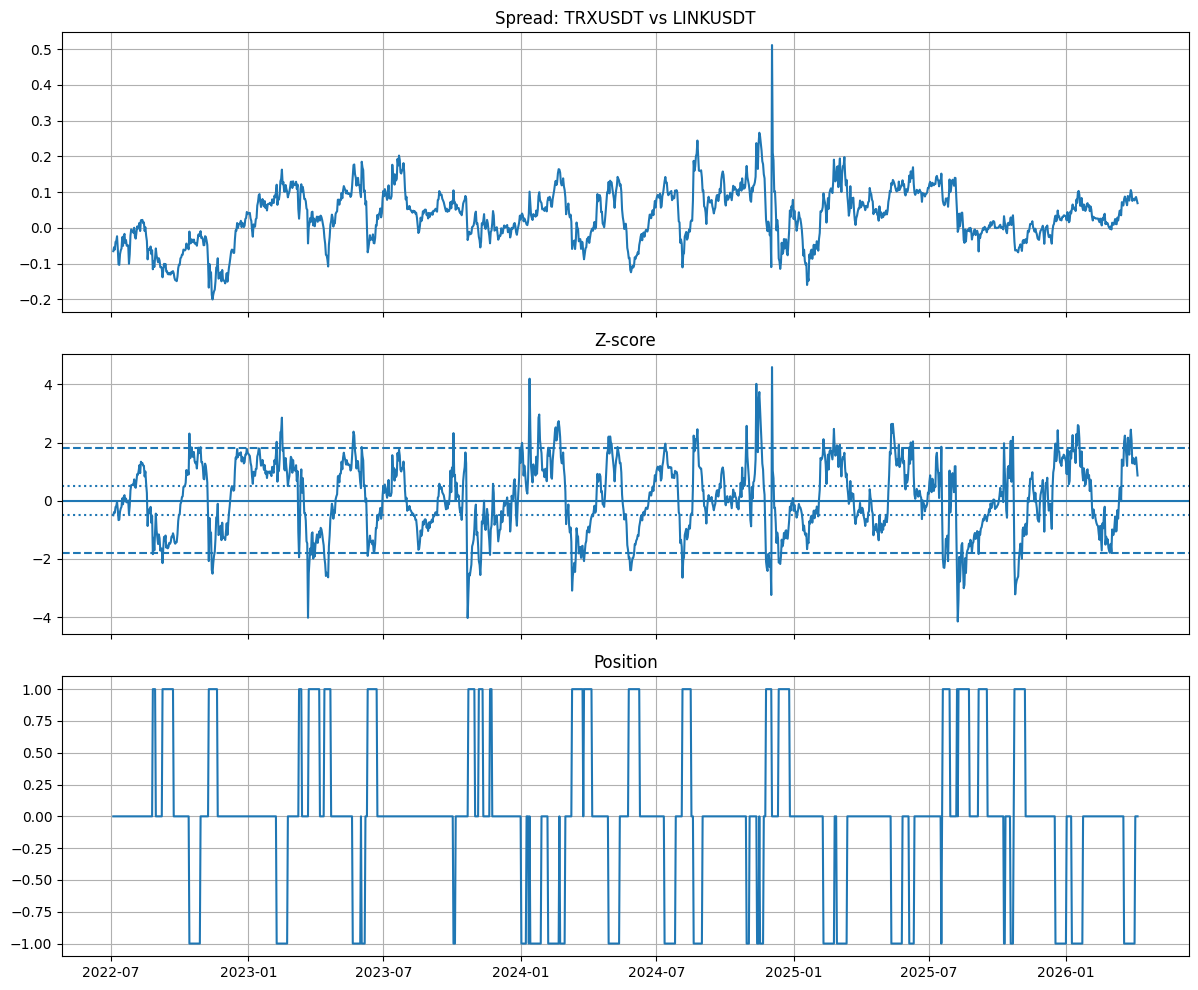

In [3]:
def build_pair_df(price_df, y_col, x_col,
                  lookback=126, z_lookback=60,
                  entry=2.0, exit=0.5,
                  stop_z=3.5, max_holding=15):

    df = price_df[[y_col, x_col]].dropna().copy()

    log_y = np.log(df[y_col])
    log_x = np.log(df[x_col])

    beta = log_y.rolling(lookback).cov(log_x) / log_x.rolling(lookback).var()
    alpha = log_y.rolling(lookback).mean() - beta * log_x.rolling(lookback).mean()

    spread = log_y - (alpha + beta * log_x)

    spread_mean = spread.rolling(z_lookback).mean()
    spread_std = spread.rolling(z_lookback).std()
    z = (spread - spread_mean) / spread_std

    raw_signal = pd.Series(np.nan, index=df.index)
    raw_signal[z > entry] = -1.0
    raw_signal[z < -entry] = 1.0
    raw_signal[z.abs() < exit] = 0.0
    raw_signal[z > stop_z] = 0.0
    raw_signal[z < -stop_z] = 0.0

    pos = pd.Series(0.0, index=df.index)

    current_pos = 0.0
    holding_days = 0

    for i in range(len(df)):
        sig = raw_signal.iloc[i]

        if current_pos == 0.0:
            if pd.notna(sig) and sig != 0.0:
                current_pos = sig
                holding_days = 1
            else:
                current_pos = 0.0
                holding_days = 0

        else:
            exit_now = False

            if pd.notna(sig) and sig == 0.0:
                exit_now = True

            if holding_days >= max_holding:
                exit_now = True

            if exit_now:
                current_pos = 0.0
                holding_days = 0
            else:
                holding_days += 1

        pos.iloc[i] = current_pos

    ret_y_log = log_y.diff()
    ret_x_log = log_x.diff()
    pair_log_ret = ret_y_log - beta.shift(1) * ret_x_log
    pair_arith_ret = np.exp(pair_log_ret) - 1.0

    out = pd.DataFrame(index=df.index)
    out["Close"] = (1.0 + pair_arith_ret.fillna(0.0)).cumprod()
    out["position"] = pos

    out["spread"] = spread
    out["z"] = z
    out["beta"] = beta.shift(1)
    out["alpha"] = alpha
    out["position_size"] = 1.0

    out = out.dropna(subset=["Close", "position", "spread", "z", "beta"])

    return out

def pair_strategy_fn(df_slice, params):
    lookback = int(params["lookback"])
    z_lookback = int(params["z_lookback"])
    entry = float(params["entry"])
    exit = float(params["exit"])
    stop_z = float(params["stop_z"])
    max_holding = int(params["max_holding"])

    if exit >= entry:
        return None

    if stop_z <= entry:
        return None

    if max_holding <= 0:
        return None

    if len(df_slice) < lookback + z_lookback + 20:
        return None

    strategy_df = build_pair_df(
        price_df=df_slice,
        y_col=Y,
        x_col=X,
        lookback=lookback,
        z_lookback=z_lookback,
        entry=entry,
        exit=exit,
        stop_z=stop_z,
        max_holding=max_holding,
    )

    if strategy_df is None or len(strategy_df) == 0:
        return None

    indicator_cols = ["spread", "z", "beta"]
    return strategy_df, indicator_cols

pair_df = build_pair_df(
    price_df=pair_prices,
    y_col=Y,
    x_col=X,
    lookback=lookback,
    z_lookback=z_lookback,
    entry=entry,
    exit=exit
)

display(pair_df.head())
display(pair_df.tail())

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(pair_df.index, pair_df["spread"])
axes[0].set_title(f"Spread: {Y} vs {X}")
axes[0].grid(True)

axes[1].plot(pair_df.index, pair_df["z"])
axes[1].axhline(entry, linestyle="--")
axes[1].axhline(-entry, linestyle="--")
axes[1].axhline(exit, linestyle=":")
axes[1].axhline(-exit, linestyle=":")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("Z-score")
axes[1].grid(True)

axes[2].plot(pair_df.index, pair_df["position"])
axes[2].set_title("Position")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [4]:
param_defs = {
    "lookback":    ("int",   80, 120),
    "z_lookback":  ("int",   60, 100),
    "entry":       ("float", 1.60, 2.10),
    "exit":        ("float", 0.50, 1.00),
    "stop_z":      ("float", 3.50, 5.00),
    "max_holding": ("int",   8,   25),
}

fixed_params = {"exit": 0.72,
    "stop_z": 4.5,
    "max_holding": 18,
    "entry": 1.9652
}   

def pair_reject(metrics):
    if metrics is None:
        return True
    if metrics["num_trades"] < 5:
        return True
    if metrics["profit_factor"] < 0.7:
        return True
    return False

test_params = {
    "lookback": 126,
    "z_lookback": 60,
    "entry": 1.8,
    "exit": 0.5,
    "stop_z": 3.5,
    "max_holding": 15,
}

pair_df, indicator_cols = pair_strategy_fn(pair_prices.copy(), test_params)

display(pair_df.head())
display(pair_df.tail())

results = backtest(
    data=pair_df,
    cost=pair_cost,
    show_plot=True,
    save_html=None,
    show_trades=False,
    benchmark_data=None
)

print(f"Pair: {Y} vs {X}")
print(f"Return        {results['total_return']*100:>8.2f}%")
print(f"Sharpe        {results['sharpe_ratio']:>8.2f}")
print(f"Max Drawdown  {results['max_drawdown']*100:>8.2f}%")
print(f"Calmar        {results['calmar_ratio']:>8.2f}")
print(f"Trades        {results['num_trades']:>8}")
print(f"Win Rate      {results['win_rate']*100:>8.2f}%")
print(f"Profit Factor {results['profit_factor']:>8.2f}")



,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2022-07-04,0.776018,0.0,-0.065191,-0.500145,-0.118245,-2.418580,1.0
2022-07-05,0.783651,0.0,-0.054050,-0.394557,-0.115197,-2.424807,1.0
2022-07-06,0.777281,0.0,-0.060726,-0.416763,-0.112551,-2.431999,1.0
2022-07-07,0.793599,0.0,-0.039085,-0.216122,-0.109462,-2.438509,1.0
2022-07-08,0.794571,0.0,-0.037050,-0.177909,-0.106479,-2.445477,1.0


,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2026-04-03,4.020065,-1.0,0.077007,1.255237,-0.009633,-1.206348,1.0
2026-04-04,4.052181,0.0,0.083536,1.439931,-0.011830,-1.199798,1.0
2026-04-05,4.069626,0.0,0.086462,1.490159,-0.014199,-1.193576,1.0
2026-04-06,4.038923,0.0,0.077529,1.163323,-0.016428,-1.188287,1.0
2026-04-07,4.009593,0.0,0.069155,0.867176,-0.018234,-1.184418,1.0


Pair: TRXUSDT vs LINKUSDT
Return          210.35%
Sharpe            0.72
Max Drawdown    -21.75%
Calmar            1.61
Trades              47
Win Rate         70.21%
Profit Factor     3.34


In [5]:
wf_results = walk_forward(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    param_defs=param_defs,
    fixed_params=fixed_params,
    train_bars=500,
    test_bars=126,
    burnin_bars=200,
    n_trials=400,
    cost=pair_cost,
    reject_fn=pair_reject,
    save_csv=None,
)

results_df = wf_results["results_df"]
all_best_params = wf_results["all_best_params"]
consensus_params = wf_results["consensus_params"]
stability_df = wf_results["stability_df"]
oos_combined_df = wf_results["oos_combined_df"]
oos_metrics = wf_results["oos_metrics"]

display(results_df)
print("Consensus params:", consensus_params)
display(stability_df)
print("OOS metrics:", oos_metrics)

sweep_results = plateau_analysis(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    base_params=wf_results["consensus_params"],
    param_defs=param_defs,
    fixed_params=fixed_params,
    cost=pair_cost,
    reject_fn=pair_reject,
    n_steps=20,
)

plateau_df = plateau_summary(
    sweep_results=sweep_results,
    base_params=wf_results["consensus_params"],
    stability_df=wf_results["stability_df"],
    threshold=0.20,
)

display(plateau_df)  

perturb_df = perturbation_test(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    base_params=wf_results["consensus_params"],
    param_defs=param_defs,
    fixed_params=fixed_params,
    cost=pair_cost,
    reject_fn=pair_reject,
    pct_offsets=(0.05, 0.10, 0.20),
    n_samples=50,
    seed=42,
)

display(perturb_df)

cost_df = cost_stress_test(
    oos_combined_df=wf_results["oos_combined_df"],
    cost_multipliers=(1.0, 1.5, 2.0, 3.0),
    base_cost=pair_cost,
)

display(cost_df)



UPDATED WALK_FORWARD FILE IS RUNNING
Walk-forward: 8 fold(s)  train=500  test=126  burnin=200  trials=400
  Fold 1: train 2022-01-01 → 2023-05-15  | test 2023-05-16 → 2023-09-18
  Fold 2: train 2022-05-07 → 2023-09-18  | test 2023-09-19 → 2024-01-22
  Fold 3: train 2022-09-10 → 2024-01-22  | test 2024-01-23 → 2024-05-27
  Fold 4: train 2023-01-14 → 2024-05-27  | test 2024-05-28 → 2024-09-30
  Fold 5: train 2023-05-20 → 2024-09-30  | test 2024-10-01 → 2025-02-03
  Fold 6: train 2023-09-23 → 2025-02-03  | test 2025-02-04 → 2025-06-09
  Fold 7: train 2024-01-27 → 2025-06-09  | test 2025-06-10 → 2025-10-13
  Fold 8: train 2024-06-01 → 2025-10-13  | test 2025-10-14 → 2026-02-16

Fixed (4): ['exit', 'stop_z', 'max_holding', 'entry']
Free  (2): ['lookback', 'z_lookback']

────────────────────────────────────────────────────────────
Fold 1/8  train: 2022-01-01 → 2023-05-15  test: 2023-05-16 → 2023-09-18


  0%|          | 0/400 [00:00<?, ?it/s]

test_m: {'total_return': np.float64(0.15694506822957055), 'sharpe_ratio': np.float64(1.951922349684275), 'max_drawdown': np.float64(-0.04684592123314102), 'win_rate': 1.0, 'num_trades': 3, 'avg_win_loss_ratio': 0.0, 'profit_factor': inf, 'calmar_ratio': np.float64(8.42216090901035), 'yearly_returns': {2023: np.float64(0.15694506822957055)}, 'yearly_sharpe': {2023: np.float64(1.9519223496842755)}, 'yearly_max_drawdown': {2023: np.float64(-0.04684592123314102)}, 'cost_percent': 0.001, 'equity_curve': Time
2023-04-12    1.000000
2023-04-13    1.000000
2023-04-14    1.000000
2023-04-15    1.000000
2023-04-16    1.000000
                ...   
2023-09-14    1.156945
2023-09-15    1.156945
2023-09-16    1.156945
2023-09-17    1.156945
2023-09-18    1.156945
Name: net_returns, Length: 160, dtype: float64, 'trades':   entry_time  exit_time  entry_price  exit_price direction       pnl
0 2023-05-21 2023-06-01     1.245433    1.229404     Short  0.012870
1 2023-06-02 2023-06-05     1.371628    1.

  0%|          | 0/400 [00:00<?, ?it/s]

test_m: {'total_return': np.float64(0.3377756788459041), 'sharpe_ratio': np.float64(4.603236376102395), 'max_drawdown': np.float64(-0.039081990747447226), 'win_rate': 1.0, 'num_trades': 6, 'avg_win_loss_ratio': 0.0, 'profit_factor': inf, 'calmar_ratio': np.float64(26.11619877104717), 'yearly_returns': {2023: np.float64(0.21636652705039916), 2024: np.float64(0.09981296681183208)}, 'yearly_sharpe': {2023: np.float64(3.817551638920311), 2024: np.float64(8.355630028703835)}, 'yearly_max_drawdown': {2023: np.float64(-0.039081990747447226), 2024: np.float64(-0.00764184121133324)}, 'cost_percent': 0.001, 'equity_curve': Time
2023-08-25    1.000000
2023-08-26    1.000000
2023-08-27    1.000000
2023-08-28    1.000000
2023-08-29    1.000000
                ...   
2024-01-18    1.337776
2024-01-19    1.337776
2024-01-20    1.337776
2024-01-21    1.337776
2024-01-22    1.337776
Name: net_returns, Length: 151, dtype: float64, 'trades':   entry_time  exit_time  entry_price  exit_price direction     

...

,param,plateau_pct,cv_fold,verdict
0,lookback,40.0,0.111236,Moderate
1,z_lookback,20.0,0.160956,FRAGILE



═══════════════════════════════════════════════════════════════════════════
PERTURBATION TEST — NEIGHBOURHOOD ROBUSTNESS
═══════════════════════════════════════════════════════════════════════════
Base score: 0.5257
  Offset  N valid     Mean   Median      Std      Min  Degradation
──────── ──────── ──────── ──────── ──────── ──────── ────────────
      5%       50   0.5185   0.5240   0.0384   0.3885        1.4%
     10%       50   0.4989   0.5045   0.0725   0.3410        5.1%
     20%       50   0.4333   0.4253   0.0651   0.3108       17.6%


,offset_pct,n_valid,mean_score,median_score,std_score,min_score,degradation
0,0.05,50,0.518495,0.523961,0.038384,0.388536,0.013693
1,0.10,50,0.498856,0.504464,0.072463,0.341029,0.051050
2,0.20,50,0.433332,0.425261,0.065122,0.310845,0.175693



═══════════════════════════════════════════════════════════════════════════
TRANSACTION COST STRESS TEST
═══════════════════════════════════════════════════════════════════════════
    Cost   Mult   Sharpe     Return      MaxDD   Calmar       PF
──────── ────── ──────── ────────── ────────── ──────── ────────
  0.0010   1.0x     1.15    459.68%    -18.36%     4.51    10.61
  0.0015   1.5x     1.13    444.52%    -18.52%     4.38    10.61
  0.0020   2.0x     1.12    429.77%    -18.68%     4.25    10.61
  0.0030   3.0x     1.09    401.44%    -19.00%     3.99    10.61


,cost,cost_mult,sharpe,total_return,max_drawdown,calmar,profit_factor,num_trades
0,0.0010,1.0,1.145390,4.596756,-0.183571,4.510910,10.605478,28
1,0.0015,1.5,1.131050,4.445225,-0.185189,4.377040,10.605478,28
2,0.0020,2.0,1.116681,4.297725,-0.186805,4.246394,10.605478,28
3,0.0030,3.0,1.087854,4.014400,-0.190029,3.994399,10.605478,28


---
## Backtest

| Parameter | Options | Default |
|---|---|---|
| `cost` | Cost per trade as decimal — `0.001` = 0.1% | `0.0` |
| `show_plot` | `True` / `False` | `True` |
| `save_html` | Filename string or `None` | `None` |
| `show_trades` | Overlay entry/exit markers on price chart | `False` |
| `benchmark_data` | DataFrame with `Close` column for buy & hold comparison | same asset |

In [6]:
from wf_visualizer import plot_walk_forward_results

plot_walk_forward_results(
    results        = wf_results,
    param_defs     = param_defs,
    fixed_params   = fixed_params,
    benchmark_data = None,       # pair strategies have no single B&H benchmark
    show           = True,
    save_html_dir  = None,
    show_fold_perf = False,
    show_param_evol= False,
    show_oos_equity= True,
    show_trades    = False,
)


In [7]:
wf_results['oos_combined_df'].to_pickle('trx_link_oos.pkl')
print('Saved trx_link_oos.pkl')


Saved trx_link_oos.pkl
